In [60]:
from llama_index.core.indices.multi_modal.base import MultiModalVectorStoreIndex
from llama_index.core.node_parser import SentenceSplitter
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import SimpleDirectoryReader, StorageContext
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.embeddings.cohere import CohereEmbedding
from dotenv import load_dotenv
from llama_index.core import PromptTemplate
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core.response.notebook_utils import display_query_and_multimodal_response
import os 
import gradio as gr

In [16]:
_ = load_dotenv(".env")

### Load images and text documents

In [17]:
def load_documents():
    """Load the context images and text into ImageDocument and Documents"""
    # context images
    image_path = "../datasets_chatbot/images"
    image_documents = SimpleDirectoryReader(image_path).load_data()
    

    # context text
    text_path = "../datasets_chatbot/descriptions"
    text_documents = SimpleDirectoryReader(text_path).load_data()

    return image_documents, text_documents

In [18]:
image_documents, text_documents = load_documents()

In [19]:
print(image_documents)
print(len(image_documents))
print(text_documents)
print(len(text_documents))

[ImageDocument(id_='1c43c17e-0c7b-4ed5-934b-0cd816e6d8e6', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\images\\14.jpg', 'file_name': '14.jpg', 'file_type': 'image/jpeg', 'file_size': 171654, 'creation_date': '2024-11-14', 'last_modified_date': '2024-10-26'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, text='', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}', metadata_template='{key}: {value}', metadata_seperator='\n', image=None, image_path='d:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\images\\14.jpg', image_url=None, image_mimetype=None, text_embedding=None), ImageDo

### Create Multimodal VectorStore Index

In [20]:
# Define the sentence splitter
node_parser = SentenceSplitter.from_defaults()

In [21]:
image_nodes = node_parser.get_nodes_from_documents(image_documents)
print(image_nodes)
print(image_nodes[0].metadata['file_path'])
print(image_nodes[1].metadata['file_path'])
print(image_nodes[2].metadata['file_path'])
print(len(image_nodes))

[ImageNode(id_='fb78fdec-af9c-4d55-ac54-e178ad7bc486', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\images\\14.jpg', 'file_name': '14.jpg', 'file_type': 'image/jpeg', 'file_size': 171654, 'creation_date': '2024-11-14', 'last_modified_date': '2024-10-26'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1c43c17e-0c7b-4ed5-934b-0cd816e6d8e6', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\images\\14.jpg', 'file_name': '14.jpg', 'file_type': 'image/jpeg', 'file_size': 171654, 'creation_date': '2024-11-14', 'last_modified_

In [22]:
text_nodes = node_parser.get_nodes_from_documents(text_documents)
print(text_nodes)
print(text_nodes[0].metadata['file_path'])
print(text_nodes[1].metadata['file_path'])
print(text_nodes[2].metadata['file_path'])
print(len(text_nodes))

[TextNode(id_='f42ab272-9271-4310-b6a2-d781e4f04935', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\descriptions\\14.txt', 'file_name': '14.txt', 'file_type': 'text/plain', 'file_size': 1047, 'creation_date': '2024-11-14', 'last_modified_date': '2024-11-13'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='9e85fa40-21f3-4978-9ec4-a947e9750b2e', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\descriptions\\14.txt', 'file_name': '14.txt', 'file_type': 'text/plain', 'file_size': 1047, 'creation_date': '2024-11-14', 'last_mo

In [23]:
# Create Cohere embedding 
embed_model = CohereEmbedding(
    api_key=os.getenv('COHERE_API_KEY')
)

In [24]:
image_embed_model = ClipEmbedding()

In [25]:
# Create multimodal index
index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = embed_model
)

In [26]:
index

In [27]:
def create_multimodal_index(image_documents, text_documents):
    # Create Cohere embedding 
    embed_model = CohereEmbedding(api_key=os.getenv('COHERE_API_KEY'))

    # cretate image embed model
    image_embed_model = ClipEmbedding()

    # Define the sentence splitter
    node_parser = SentenceSplitter.from_defaults()
    image_nodes = node_parser.get_nodes_from_documents(image_documents)
    text_nodes = node_parser.get_nodes_from_documents(text_documents)

    # Create multimodal index
    index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = embed_model
    )

    return index


###  Multi-Modal Rag 

In [29]:
# Define Prompt Template
prompt_template = (
    "Images of shoes are provided.\n"
    "---------------------\n"
    "{context}\n"
    "---------------------\n"
    "If the images provided cannot help in answering the query\n"
    "then respond that you are unable to answer the query. Otherwise,\n"
    "using only the context provided, and not prior knowledge,\n"
    "provide an answer to the query."
    "Query: {query}\n"
    "Answer: "
)
prompt = PromptTemplate(prompt_template)

prompt

PromptTemplate(metadata={'prompt_type': <PromptType.CUSTOM: 'custom'>}, template_vars=['context', 'query'], kwargs={}, output_parser=None, template_var_mappings=None, function_mappings=None, template='Images of shoes are provided.\n---------------------\n{context}\n---------------------\nIf the images provided cannot help in answering the query\nthen respond that you are unable to answer the query. Otherwise,\nusing only the context provided, and not prior knowledge,\nprovide an answer to the query.Query: {query}\nAnswer: ')

#### LLAVA 13B

In [39]:
# Instantiate the Ollama MultiModal LLM
mm_model = OllamaMultiModal(model="llava:13b", request_timeout=60.0)

# Define rag query engine (Motor de Búsqueda)
rag_engine = index.as_query_engine(
    llm = mm_model,
    text_qa_template = prompt
)

# Retrieve settings. Finde the most relevant document
rag_engine.retriever.image_similarity_top_k = 1

Query: Tell me more about the Cowboy Boots
Retrieved Images:



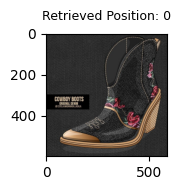

Response:  The image shows a pair of cowboy boots with a denim texture. They have a floral pattern on them, which appears to be roses or similar flowers. These boots are designed for women and feature a medium heel, making them suitable for casual wear or as part of a stylish outfit that incorporates a western theme. The boots are branded with "COWBOY BOOTS," indicating that they are specifically designed to evoke the style typically associated with cowboys or rodeo attire.



In [42]:
# Query the multimodal RAG 
query = "Tell me more about the Cowboy Boots"
response = rag_engine.query(query)
display_query_and_multimodal_response(query, response)

Query: Show me images of sneakers
Retrieved Images:



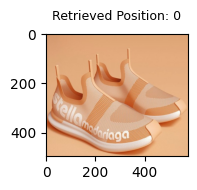

Response:  The image shows a pair of sneakers from the brand "Stella McCartney." These shoes feature a distinctive design with a mesh-like upper and a chunky sole. The color scheme appears to be light, possibly in shades of orange or cream, complemented by what seems to be metallic accents on the laces or other details.



In [50]:
# Query the multimodal RAG 
query = "Show me images of sneakers"
response = rag_engine.query(query)
display_query_and_multimodal_response(query, response)

Query: Show me images of sandals
Retrieved Images:



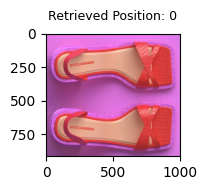

Response:  The image shows a pair of red strappy sandals with open-toed designs. They have high heels and appear to be made from a material that gives them a glossy look. If you need more information or clarification on the shoes, please provide additional context.



In [51]:
# Query the multimodal RAG 
query = "Show me images of sandals"
response = rag_engine.query(query)
display_query_and_multimodal_response(query, response)

#### LLama3.2-vision 11B

In [46]:
# Instantiate the Ollama MultiModal LLM
mm_model_2 = OllamaMultiModal(model="llama3.2-vision:11b")

# Define rag query engine (Motor de Búsqueda)
rag_engine_2 = index.as_query_engine(
    llm = mm_model_2,
    text_qa_template = prompt
)

# Retrieve settings. Finde the most relevant document
rag_engine_2.retriever.image_similarity_top_k = 1

Query: Tell me more about the Cowboy Boots
Retrieved Images:



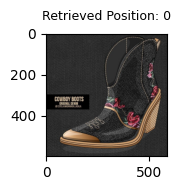

Response: The image of shoes is of cowboy boots. The question asks for the type of shoe in the image.

Since the image shows a pair of cowboy boots, the answer would be:

*Answer*: Cowboy boots



In [ ]:
# Query the multimodal RAG 
query = "Tell me more about the Cowboy Boots"
response_2 = rag_engine_2.query(query)
display_query_and_multimodal_response(query, response_2)

Query: Show me images of sneakers.
Retrieved Images:



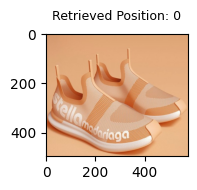

Response: The image shows a pair of shoes with the brand name "Stella Madariaga" on them.

* The shoes are light-colored and have a mesh material.
	+ They appear to be slip-on style shoes, without laces or zippers.
	+ The soles of the shoes are white and appear to be made of a rubber-like material.
* The brand name "Stella Madariaga" is written in large letters on the side of one shoe.
	+ The font is bold and cursive, with a decorative flourish at the end of each letter.
	+ The text is colored to match the rest of the shoe, creating a cohesive look.

Overall, the image suggests that Stella Madariaga is a fashion brand that specializes in casual, comfortable footwear.



In [48]:
# Query the multimodal RAG 
query = "Show me images of sneakers."
response = rag_engine_2.query(query)
display_query_and_multimodal_response(query, response)

<class 'llama_index.core.base.response.schema.Response'>
Query: Show me images of sandals.
Retrieved Images:



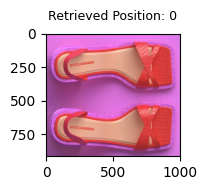

Response: The image shows a pair of shoes with the brand name "BY ESTELA MADARIAGA" printed on them.

**Step-by-Step Answer**

* The image shows a pair of shoes.
* The shoes have a pink sole and a beige upper part.
* The brand name "BY ESTELA MADARIAGA" is printed on the inside of the shoe, visible when looking down from above.
* The brand name suggests that the shoes are designed by Estela Madariaga, likely a designer or fashion brand.

**Answer**: BY ESTELA MADARIAGA



In [64]:
# Query the multimodal RAG 
query = "Show me images of sandals."
response = rag_engine_2.query(query)
print(type(response))
display_query_and_multimodal_response(query, response)

In [67]:
print(type(response.response))

<class 'str'>


In [104]:
response.metadata['image_nodes'][0].metadata['file_path'] 

'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\images\\14.jpg'

In [105]:
response.metadata['text_nodes'][0].metadata['file_path'] 

'd:\\workspace\\proyecto_tfg\\poc_multimod_chatbot_chroma\\notebooks\\..\\datasets_chatbot\\descriptions\\14.txt'

#### Utils

In [54]:
def load_documents():
    """Load the context images and text into ImageDocument and Documents"""
    # context images
    image_path = "../datasets_chatbot/images"
    image_documents = SimpleDirectoryReader(image_path).load_data()
    

    # context text
    text_path = "../datasets_chatbot/descriptions"
    text_documents = SimpleDirectoryReader(text_path).load_data()

    return image_documents, text_documents

In [55]:
def create_multimodal_index(image_documents, text_documents):
    # Create Cohere embedding 
    embed_model = CohereEmbedding(api_key=os.getenv('COHERE_API_KEY'))

    # cretate image embed model
    image_embed_model = ClipEmbedding()

    # Define the sentence splitter
    node_parser = SentenceSplitter.from_defaults()
    image_nodes = node_parser.get_nodes_from_documents(image_documents)
    text_nodes = node_parser.get_nodes_from_documents(text_documents)

    # Create multimodal index
    index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = embed_model
    )

    return index

In [77]:
def multimodal_rag(index, llm='llava:13b'):

    # Define Prompt Template
    prompt_template = (
    "Images of shoes are provided.\n"
    "---------------------\n"
    "{context}\n"
    "---------------------\n"
    "If the images provided cannot help in answering the query\n"
    "then respond that you are unable to answer the query. Otherwise,\n"
    "using only the context provided, and not prior knowledge,\n"
    "provide an answer to the query."
    "Query: {query}\n"
    "Answer: "
    )

    prompt = PromptTemplate(prompt_template)

    # Instantiate the Ollama MultiModal LLM
    mm_model = OllamaMultiModal(model=llm, request_timeout=60.0)

    # Define rag query engine (Motor de Búsqueda)
    rag_engine = index.as_query_engine(
    llm = mm_model,
    text_qa_template = prompt
    )

    # Retrieve settings. Finde the most relevant document
    rag_engine.retriever.image_similarity_top_k = 1

    return rag_engine

In [78]:
def query_multimodal_rag(rag_engine, query):
    response = rag_engine.query(query)
    #display_query_and_multimodal_response(query, response)
    return response

### Interfaz sin multimodalidad 

In [128]:
def rag_respond(message, history):
    response = query_multimodal_rag(rag_engine, message)
    return response.response

In [129]:
demo = gr.ChatInterface(
    fn=rag_respond, 
    type="messages", 
    title="Multimodal Chatbot", multimodal=False)

In [ ]:
# Crocodrile Sandals
demo.launch()

Running on local URL:  http://127.0.0.1:7873

To create a public link, set `share=True` in `launch()`.


### Interfaz con multimodalidad

In [142]:
def rag_respond( query):
    response = query_multimodal_rag(rag_engine, query)
    return  gr.Image(response.metadata['image_nodes'][0].metadata['file_path']), response.response

In [143]:
demo = gr.Interface(
    fn=rag_respond, 
    title="Multimodal Chatbot",
    inputs=[gr.Textbox()],   
    outputs=[gr.Image(), gr.Textbox()] )

In [144]:
demo.launch()

Running on local URL:  http://127.0.0.1:7878

To create a public link, set `share=True` in `launch()`.
